# NABat EDA 

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import zipfile
import io
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-white')
plt.rcParams['axes.grid'] = False
sns.set_palette('husl')

In [ ]:
DATA_DIR = "/Users/katterns/ITMO/Practice/cleaned"
MAX_FILES_PER_CLASS = 20 

## 1. Загрузка метаданных
Используем готовый CSV — не нужно читать каждый файл!

In [ ]:
df = pd.read_csv(os.path.join(DATA_DIR, "audio_metadata_cleaned.csv"))
df = df.rename(columns={'species': 'class', 'duration': 'duration_sec'})

print(f"Количество записей: {len(df):,}")
print(f"Классов: {df['class'].nunique()}")
print(f"Длительность: {df['duration_sec'].sum()/3600:.1f} часов")

Количество записей: 17,122
Классов: 26
Длительность: 22.8 часов


## 2. Статистика по классам

In [4]:
stats = df.groupby('class').agg({
    'filename': 'count',
    'duration_sec': ['sum', 'mean', 'std']
}).round(3)
stats.columns = ['count', 'total_duration', 'mean_duration', 'std_duration']
stats = stats.sort_values('count', ascending=False)

## 3. Визуализация распределения

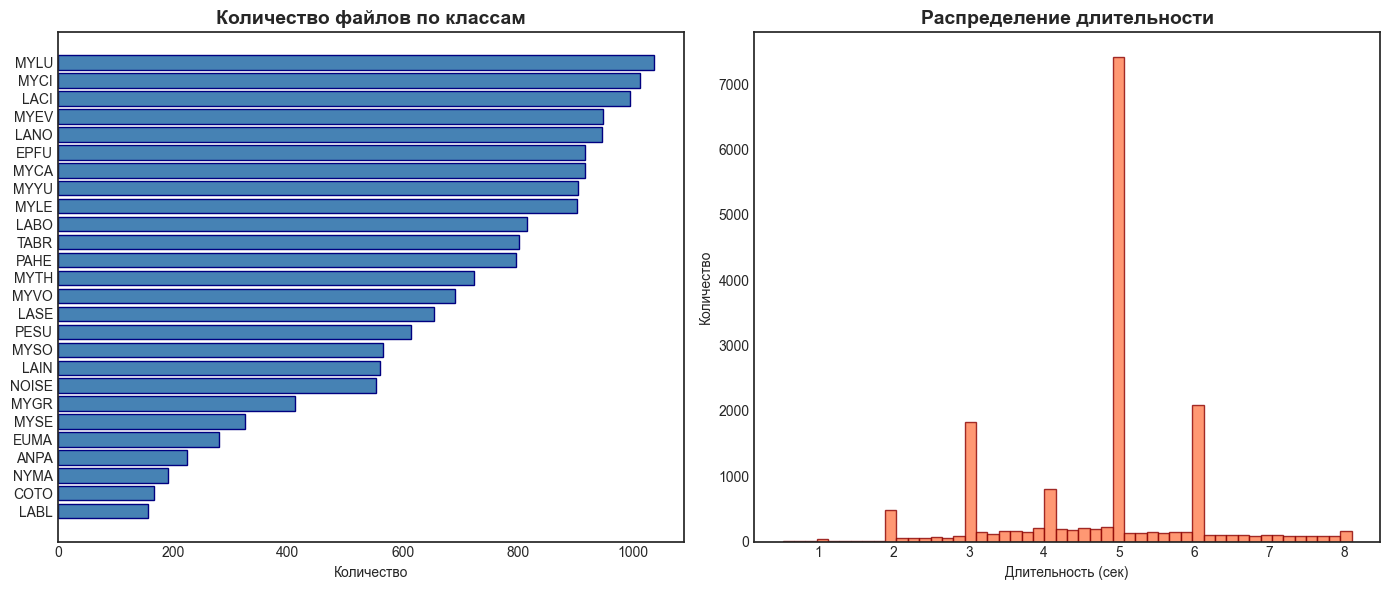

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_counts = df['class'].value_counts()
axes[0].barh(class_counts.index, class_counts.values, color='steelblue', edgecolor='navy')
axes[0].set_title('Количество файлов по классам', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Количество')
axes[0].invert_yaxis()

axes[1].hist(df['duration_sec'], bins=50, color='coral', edgecolor='darkred', alpha=0.8)
axes[1].set_title('Распределение длительности', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Длительность (сек)')
axes[1].set_ylabel('Количество')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Функции для работы с аудио

In [6]:
def load_audio_from_zip(species, filename, sr=None):
    """Загружает аудио из zip архива"""
    zip_path = os.path.join(DATA_DIR, f"{species}.zip")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(filename) as f:
            audio, sample_rate = librosa.load(io.BytesIO(f.read()), sr=sr)
    return audio, sample_rate

def apply_wiener_filter(audio, noise_sensitivity=3.5):
    """Фильтр Винера для шумоподавления"""
    stft = librosa.stft(audio)
    magnitude = np.abs(stft)
    phase = np.angle(stft)
    
    noise_frames = magnitude[:, :int(0.3 * len(audio) / 512)]
    noise_power = np.mean(noise_frames ** 2, axis=1, keepdims=True) * noise_sensitivity
    
    signal_power = magnitude ** 2
    snr = signal_power / (noise_power + 1e-10)
    gain = np.maximum(1 - noise_sensitivity / (snr + 1), 0.05)
    gain[snr < 1.0] *= 0.3
    
    filtered_stft = (magnitude * gain) * np.exp(1j * phase)
    return librosa.istft(filtered_stft)

## 5. Частотный анализ

In [ ]:
class_frequency_analysis = {}

for class_name in tqdm(df['class'].unique()):
    class_files = df[df['class'] == class_name]
    
    if len(class_files) > MAX_FILES_PER_CLASS:
        class_files = class_files.sample(n=MAX_FILES_PER_CLASS, random_state=42)
    
    all_frequencies = []
    all_spectral_centroids = []
    processed = 0
    
    for _, row in class_files.iterrows():
    
        audio, sr = load_audio_from_zip(class_name, row['filename'])
        
        fft = np.fft.fft(audio)
        magnitude = np.abs(fft)[:len(fft)//2]
        frequencies = np.linspace(0, sr/2, len(magnitude))

        top_freq = frequencies[np.argsort(magnitude)[-5:][::-1]]
        all_frequencies.extend(top_freq)
        
        centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
        all_spectral_centroids.extend(centroid)
        
        processed += 1
    
    if processed > 0:
        class_frequency_analysis[class_name] = {
            'mean_dominant_freq': np.mean(all_frequencies),
            'freq_range': [np.min(all_frequencies), np.max(all_frequencies)],
            'mean_spectral_centroid': np.mean(all_spectral_centroids),
            'processed_files': processed
        }

  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [01:49<00:00,  4.21s/it]


## 6. Визуализация сигналов (~3-5 мин)
Показываем по одному файлу на класс — оригинал и после фильтра Винера

Визуализация:   0%|          | 0/4 [00:00<?, ?it/s]

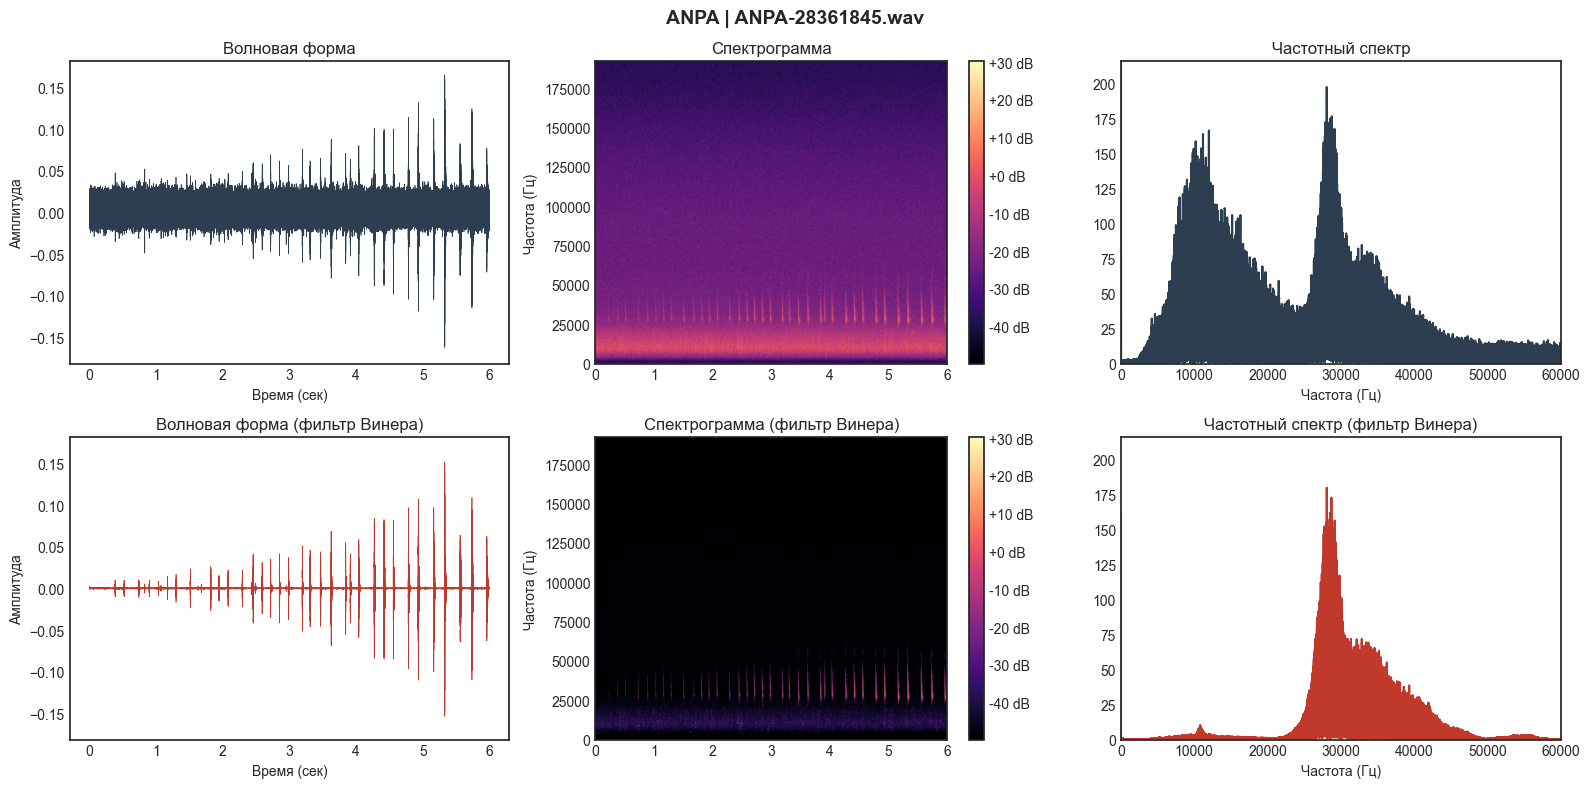

Визуализация:  25%|██▌       | 1/4 [00:01<00:04,  1.39s/it]

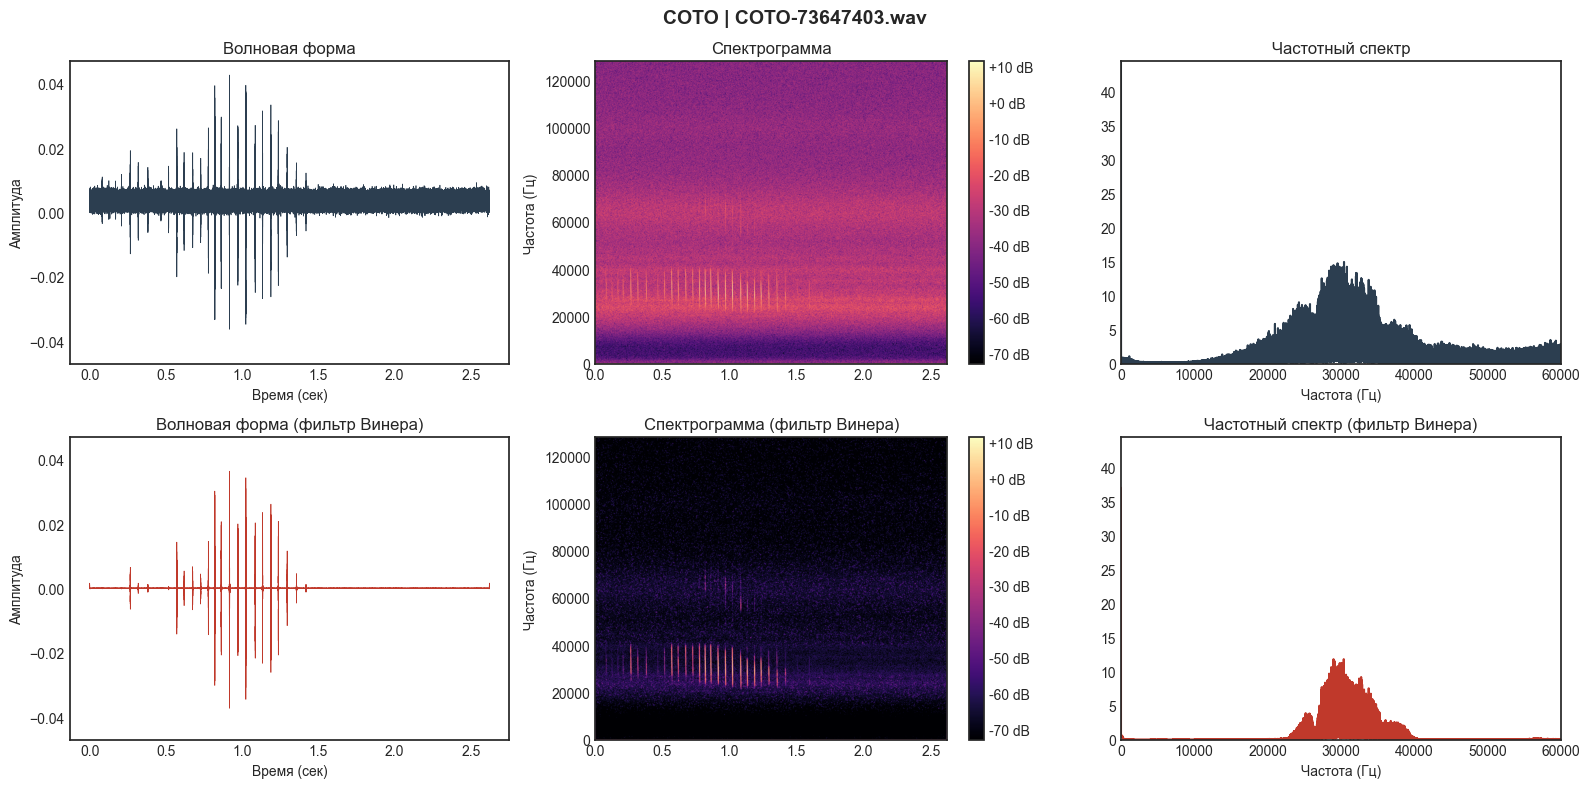

Визуализация:  50%|█████     | 2/4 [00:01<00:01,  1.13it/s]

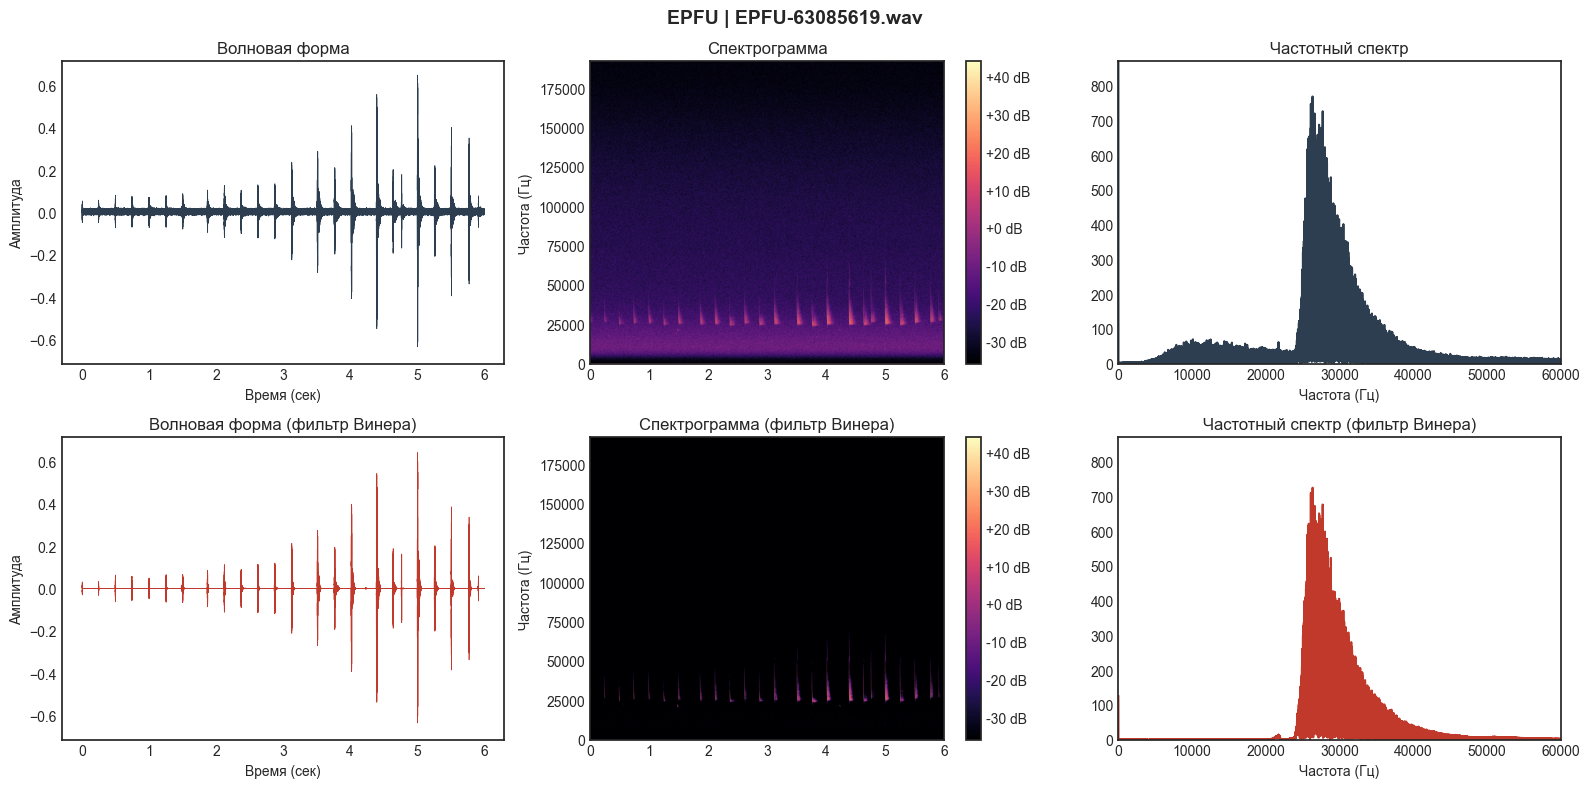

Визуализация:  75%|███████▌  | 3/4 [00:03<00:01,  1.06s/it]

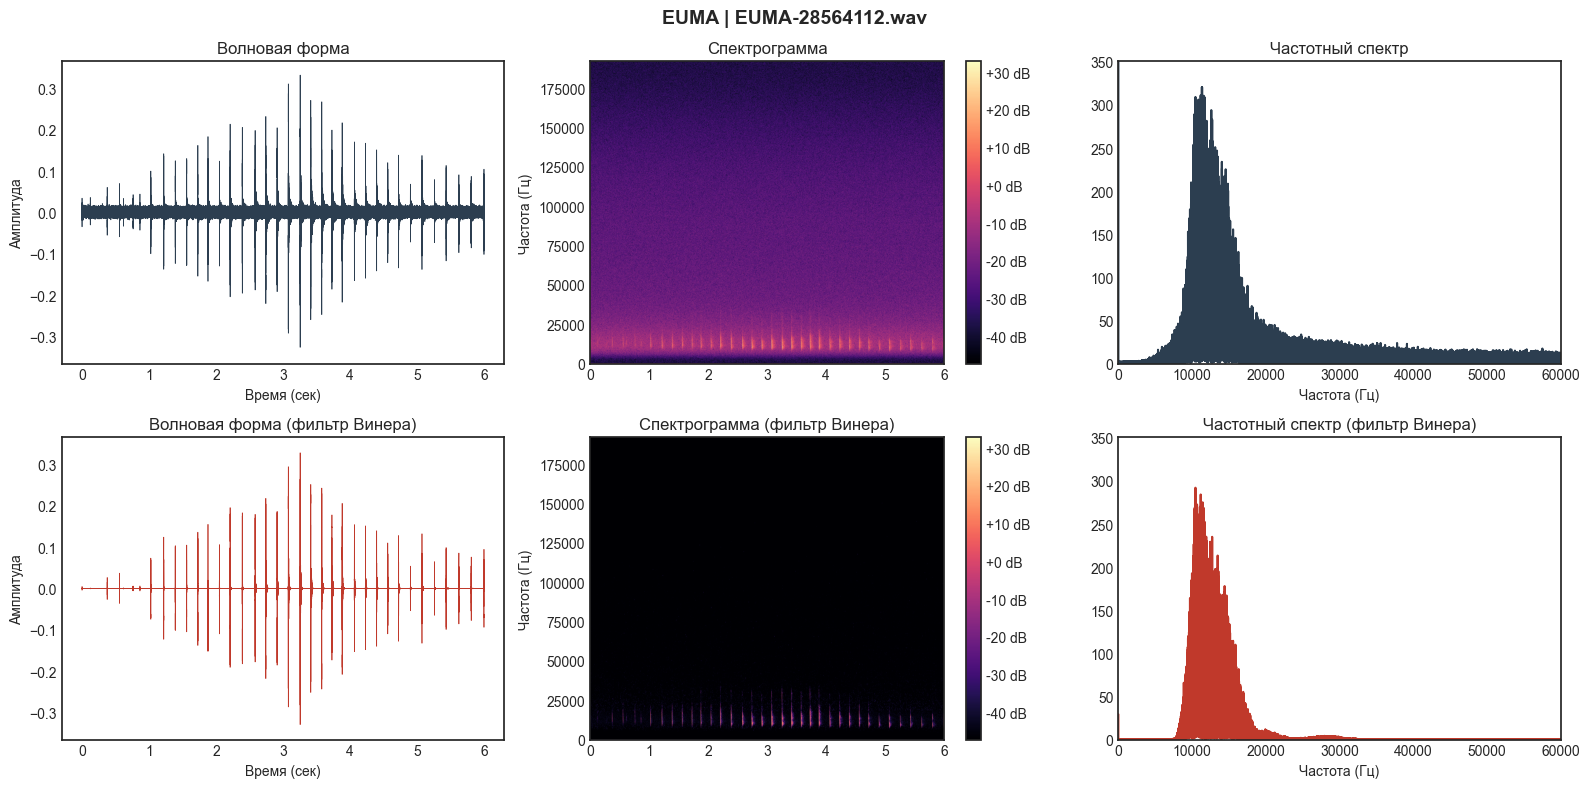

Визуализация: 100%|██████████| 4/4 [00:04<00:00,  1.12s/it]


In [ ]:
CLASSES_TO_SHOW = sorted(class_frequency_analysis.keys())[:4] 

for class_name in tqdm(CLASSES_TO_SHOW, desc="Визуализация"):

    class_files = df[df['class'] == class_name]
    sample_file = class_files.iloc[0]
    
    audio_orig, sr = load_audio_from_zip(class_name, sample_file['filename'])
    audio_filt = apply_wiener_filter(audio_orig)

    time = np.arange(len(audio_orig)) / sr
    X_orig = librosa.amplitude_to_db(np.abs(librosa.stft(audio_orig)))
    X_filt = librosa.amplitude_to_db(np.abs(librosa.stft(audio_filt)))
    fft_orig = np.abs(np.fft.fft(audio_orig))[:len(audio_orig)//2]
    fft_filt = np.abs(np.fft.fft(audio_filt))[:len(audio_filt)//2]
    freqs = np.linspace(0, sr/2, len(fft_orig))
    
    amp_lim = max(np.abs(audio_orig).max(), np.abs(audio_filt).max()) * 1.1
    spec_vmin = min(X_orig.min(), X_filt.min())
    spec_vmax = max(X_orig.max(), X_filt.max())
    fft_lim = max(np.percentile(fft_orig, 99), fft_filt.max()) * 1.2
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle(f'{class_name} | {sample_file["filename"]}', fontsize=14, fontweight='bold')
    
    # оригинал - волновая форма
    axes[0, 0].plot(time, audio_orig, color='#2c3e50', linewidth=0.5)
    axes[0, 0].set_title('Волновая форма')
    axes[0, 0].set_xlabel('Время (сек)')
    axes[0, 0].set_ylabel('Амплитуда')
    axes[0, 0].set_ylim(-amp_lim, amp_lim)
    
    # оригинал - спектрограмма
    im1 = axes[0, 1].imshow(X_orig, aspect='auto', origin='lower',
                            extent=[0, len(audio_orig)/sr, 0, sr/2], 
                            cmap='magma', vmin=spec_vmin, vmax=spec_vmax)
    axes[0, 1].set_title('Спектрограмма')
    axes[0, 1].set_ylabel('Частота (Гц)')
    plt.colorbar(im1, ax=axes[0, 1], format='%+2.0f dB')
    
    # оригинал - частотный спектр
    axes[0, 2].plot(freqs, fft_orig, color='#2c3e50')
    axes[0, 2].set_title('Частотный спектр')
    axes[0, 2].set_xlabel('Частота (Гц)')
    axes[0, 2].set_xlim(0, min(60000, sr/2))
    axes[0, 2].set_ylim(0, fft_lim)
    
    # после фильтра - волновая форма
    axes[1, 0].plot(time[:len(audio_filt)], audio_filt, color='#c0392b', linewidth=0.5)
    axes[1, 0].set_title('Волновая форма (фильтр Винера)')
    axes[1, 0].set_xlabel('Время (сек)')
    axes[1, 0].set_ylabel('Амплитуда')
    axes[1, 0].set_ylim(-amp_lim, amp_lim)
    
    # после фильтра - спектрограмма
    im2 = axes[1, 1].imshow(X_filt, aspect='auto', origin='lower',
                            extent=[0, len(audio_filt)/sr, 0, sr/2], 
                            cmap='magma', vmin=spec_vmin, vmax=spec_vmax)
    axes[1, 1].set_title('Спектрограмма (фильтр Винера)')
    axes[1, 1].set_ylabel('Частота (Гц)')
    plt.colorbar(im2, ax=axes[1, 1], format='%+2.0f dB')
    
    # после фильтра - частотный спектр
    axes[1, 2].plot(freqs[:len(fft_filt)], fft_filt, color='#c0392b')
    axes[1, 2].set_title('Частотный спектр (фильтр Винера)')
    axes[1, 2].set_xlabel('Частота (Гц)')
    axes[1, 2].set_xlim(0, min(60000, sr/2))
    axes[1, 2].set_ylim(0, fft_lim)
    
    plt.tight_layout()
    plt.show()
        

## 7. Сводная таблица характеристик

In [ ]:
characteristics = []

for class_name in sorted(class_frequency_analysis.keys()):
    feat = class_frequency_analysis[class_name]
    class_stats = stats.loc[class_name] if class_name in stats.index else None
    
    characteristics.append({
        'Класс': class_name,
        'Файлов': int(class_stats['count']) if class_stats is not None else 0,
        'Ср. длительность (сек)': f"{class_stats['mean_duration']:.2f}" if class_stats is not None else '-',
        'Частотный диапазон (Гц)': f"{feat['freq_range'][0]:.0f} - {feat['freq_range'][1]:.0f}",
        'Доминирующая частота (Гц)': f"{feat['mean_dominant_freq']:.0f}"
    })

char_df = pd.DataFrame(characteristics)
display(char_df)

char_df.to_csv(os.path.join(DATA_DIR, 'characteristics.csv'), index=False)

,Класс,Файлов,Ср. длительность (сек),Частотный диапазон (Гц),Доминирующая частота (Гц)
0,ANPA,225,5.34,0 - 40403,14569
1,COTO,167,4.80,0 - 38615,17888
2,EPFU,917,4.73,0 - 35866,19392
3,EUMA,280,5.28,0 - 31909,9447
4,LABL,157,5.25,0 - 49308,12262
5,LABO,816,4.54,0 - 48643,28081
6,LACI,995,4.80,0 - 24118,11714
7,LAIN,560,5.66,0 - 11823,5063
8,LANO,946,4.89,0 - 28039,19319
9,LASE,655,5.14,0 - 41732,8847
